<a href="https://colab.research.google.com/github/Existanze54/sirius-neural-networks-2026/blob/main/Seminars/S05_CNN_part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Нейронные сети в биоинформатике

### Семинар 5: Конволюционные нейронные сети. Продолжение

# Задача 1. Классификация здоровых и зараженных малярией клеток

Загрузим данные с фотографиями зараженных и незараженных малярией клеток

In [ ]:
!wget https://kodomo.fbb.msu.ru/FBB/ml/malaria_dataset.zip

--2026-03-06 07:44:17--  https://kodomo.fbb.msu.ru/FBB/ml/malaria_dataset.zip
Resolving kodomo.fbb.msu.ru (kodomo.fbb.msu.ru)... 93.180.63.127
Connecting to kodomo.fbb.msu.ru (kodomo.fbb.msu.ru)|93.180.63.127|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 353903672 (338M) [application/zip]
Saving to: ‘malaria_dataset.zip’

malaria_dataset.zip 100%[===================>] 337.51M  26.2MB/s    in 14s     

2026-03-06 07:44:32 (24.3 MB/s) - ‘malaria_dataset.zip’ saved [353903672/353903672]



In [ ]:
!unzip malaria_dataset.zip > /dev/null

Посмотрим на несколько наших картинок

In [ ]:
from IPython.display import Image

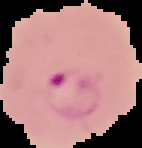

In [ ]:
Image(filename="cell_images/Parasitized/C100P61ThinF_IMG_20150918_144104_cell_162.png")

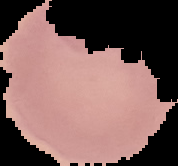

In [ ]:
Image(filename="cell_images/Uninfected/C99P60ThinF_IMG_20150918_140900_cell_66.png")

Немного видоизменим наши картинки при помощи набора преобразований. Для этого импортируем эти преобразования из pytorchvision

In [ ]:
import torch
from torchvision.transforms import Compose,  ToTensor, Resize

transform=Compose([Resize((32,32)),
                  ToTensor()])

Загрузим наш датасет

In [ ]:
from torchvision import datasets
data = datasets.ImageFolder(root="cell_images",
                            transform=transform)

Посмотрим на размер наших данных

In [ ]:
df_size=len(data)
print('Size = {}'.format(df_size))

Разобьем наши данные на обучение и тест. Какой-то явной дополнительной структуры в датасете не прослеживается, потому просто разобьем на обучение и валидацию

In [ ]:
from tqdm import tqdm
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms

In [ ]:
TEST_SIZE = int(0.25 * df_size)
VAL_SIZE = int(0.25 * (df_size - TEST_SIZE))

all_train_dataset, test_dataset = torch.utils.data.random_split(data,
                                                            [df_size - TEST_SIZE, TEST_SIZE],
                                                            generator=torch.Generator().manual_seed(42))

train_dataset, val_dataset = torch.utils.data.random_split(all_train_dataset,
                                                            [df_size - TEST_SIZE - VAL_SIZE, VAL_SIZE],
                                                            generator=torch.Generator().manual_seed(42))

In [ ]:
import torch

train_loader=torch.utils.data.DataLoader(train_dataset,
                                         batch_size=128,
                                         shuffle=True)

val_loader=torch.utils.data.DataLoader(#YOUR CODE HERE)

test_loader=torch.utils.data.DataLoader(#YOUR CODE HERE)

In [ ]:
class ConvNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.featurizer = nn.Sequential(nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3),
                                        nn.ReLU(),
                                        nn.MaxPool2d(kernel_size=2),
                                        # Conv2d 3x3, in_c = 8, out channels = 32,
                                        nn.ReLU(),
                                        # MaxPool 2x2
                                        )
        self.fc = nn.Sequential(nn.Flatten(),
                                # linear layer 32 * 6 * 6 -> 64
                                nn.ReLU(),
                                nn.Linear(64, 1))

    def forward(self, x):
        x = self.featurizer(x)
        x = self.fc(x)
        return x

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [ ]:
model = ConvNet().to(device)
print(model)

In [ ]:
import torch.optim as optim
import torch.nn.functional as F

criteria=nn.BCEWithLogitsLoss()
optimizer=optim.Adam(model.parameters())


Обучим модель

In [ ]:
NUM_EPOCHS=10

In [ ]:
for epoch in range(NUM_EPOCHS):
    model.train()
    train_loss = 0
    print("%{}".format(epoch*100/NUM_EPOCHS))
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        inputs = inputs.to(device)
        labels = labels.unsqueeze(1).float()
        labels = labels.to(device)

        outputs = model(inputs)
        loss = criteria(outputs, labels)
        train_loss += loss.detach() * labels.shape[0]
        # we must backpropagate gradient YOUR CODE HERE
        optimizer.step()
    print(train_loss / len(train_dataset))


    val_loss = 0
    model.eval()
    for inputs, labels in val_loader:
      with torch.no_grad():
          inputs = inputs.to(device)
          labels = labels.unsqueeze(1).float()
          labels = labels.to(device)

          outputs = model(inputs)
          loss = criteria(outputs, labels)
          val_loss += loss.detach() * labels.shape[0]

    print(val_loss / len(val_dataset))

print('Finished Training')

In [ ]:
print("\nTesting...")

y_true = []
y_pred = []

model.eval()
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)

        y_true.append(labels.numpy())

        outputs = model(inputs)

        probs = torch.sigmoid(outputs)
        predicted = probs > 0.5
        y_pred.append(predicted.squeeze(1).cpu().numpy())

print("\nFinished Training")

In [ ]:
y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)

In [ ]:
np.mean(y_true == y_pred)

## Правильное разбиение

А теперь внимательно прочитаем [описание](https://lhncbc.nlm.nih.gov/LHC-publications/pubs/MalariaDatasets.html) датасета и обнаружим, что вообще-то говоря, разные клетки взяты от разных пациентов. Более того, у больных пациентов были и здоровые клетки, которые тоже были добавлены в датасет

In [ ]:
!wget  https://data.lhncbc.nlm.nih.gov/public/Malaria/patientid_cellmapping_parasitized.csv
!wget  https://data.lhncbc.nlm.nih.gov/public/Malaria/patientid_cellmapping_uninfected.csv

In [ ]:
infected_images = {}

with open("patientid_cellmapping_parasitized.csv") as inp:
    for line in inp:
        name, images = line.strip().split(",", 1)
        name = name.strip()
        images = images.replace("[", "").replace("]", "").split(",")
        images = [x.strip().replace("'", "") for x in images]
        images = [x for x in images if x]

        infected_images[name] = images

In [ ]:
uninfected_images = {}
with open("patientid_cellmapping_uninfected.csv") as inp:
    for line in inp:
        name, images = line.strip().split(",", 1)
        name = name.strip()
        images = images.replace("[", "").replace("]", "").split(",")
        images = [x.strip().replace("'", "") for x in images]
        images = [x for x in images if x]

        uninfected_images[name] = images

In [ ]:
infected = list(infected_images.keys())

Поделим больных так, чтобы в трейн попало порядка 80% фотографий больных клеток

In [ ]:
infected_train = []
count_train = 0
infected_val = []
count_val = 0

for inf in infected:
    if  count_val * 4 > count_train :
        infected_train.append(inf)
        count_train += len(infected_images[inf])
    else:
        infected_val.append(inf)
        count_val += len(infected_images[inf])

In [ ]:
count_val, count_train

In [ ]:
count_val / (count_train + count_val)

In [ ]:
len(infected_train), len(infected_val)

Поделим аналогично здоровых

In [ ]:
uninfected = list(set(uninfected_images.keys()) - set(infected))

Учтем, что у больных тоже были здоровые эритроциты

In [ ]:
uninfected_train = []
count_train = sum( len(uninfected_images[inf]) for inf in infected_train)
uninfected_val = []
count_val = sum( len(uninfected_images[inf]) for inf in infected_val)

for uninf in uninfected:
    if  count_val * 4 > count_train :
        uninfected_train.append(uninf)
        count_train += len(uninfected_images[uninf])
    else:
        uninfected_val.append(uninf)
        count_val+= len(uninfected_images[uninf])

In [ ]:
count_val, count_train

In [ ]:
count_val / (count_train + count_val)

In [ ]:
len(uninfected_train), len(uninfected_val)

Теперь сделаем два датасета - для обучения и тестирования

In [ ]:
import os
import shutil
try:
  os.mkdir("train")
except FileExistsError:
  pass
try:
  os.mkdir("train/infected")
except FileExistsError:
  pass

for inf in infected_train:
    for img in infected_images[inf]:
        prev_path = os.path.join("cell_images/Parasitized", img)
        cur_path = os.path.join("train/infected", img)
        shutil.copy(prev_path, cur_path)
try:
  os.mkdir("train/uninfected")
except FileExistsError:
  pass
for inf in infected_train:
    for img in uninfected_images[inf]:
        prev_path = os.path.join("cell_images/Uninfected", img)
        cur_path = os.path.join("train/uninfected", img)
        shutil.copy(prev_path, cur_path)
for inf in uninfected_train:
    for img in uninfected_images[inf]:
        prev_path = os.path.join("cell_images/Uninfected", img)
        cur_path = os.path.join("train/uninfected", img)
        shutil.copy(prev_path, cur_path)

In [ ]:
!ls train/uninfected | wc -l
!ls train/infected | wc -l

In [ ]:
import os
import shutil
try:
  os.mkdir("val")
except FileExistsError:
  pass
try:
  os.mkdir("val/infected")
except FileExistsError:
  pass

for inf in infected_val:
    for img in infected_images[inf]:
        prev_path = os.path.join("cell_images/Parasitized", img)
        cur_path = os.path.join("val/infected", img)
        shutil.copy(prev_path, cur_path)

try:
  os.mkdir("val/uninfected")
except FileExistsError:
  pass
for inf in infected_val:
    for img in uninfected_images[inf]:
        prev_path = os.path.join("cell_images/Uninfected", img)
        cur_path = os.path.join("val/uninfected", img)
        shutil.copy(prev_path, cur_path)
for inf in uninfected_val:
    for img in uninfected_images[inf]:
        prev_path = os.path.join("cell_images/Uninfected", img)
        cur_path = os.path.join("val/uninfected", img)
        shutil.copy(prev_path, cur_path)

In [ ]:
!ls val/uninfected | wc -l
!ls val/infected | wc -l

Теперь загрузим эти датасеты

In [ ]:
from torchvision.datasets import ImageFolder

In [ ]:
train_dataset = ImageFolder('train', transform=transform)
val_dataset = ImageFolder('val', transform=transform)

In [ ]:
assert train_dataset.class_to_idx == val_dataset.class_to_idx


In [ ]:
train_loader=torch.utils.data.DataLoader(#YOUR CODE HERE,
                                         batch_size=128,
                                         shuffle=True)

val_loader=torch.utils.data.DataLoader(#YOUR CODE HERE,
                                       batch_size=128)

In [ ]:
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

In [ ]:
device= torch.device("cuda")

In [ ]:
net = ConvNet().to(device)
print(net)
criterion=nn.BCEWithLogitsLoss()
optimizer=optim.Adam(net.parameters())
NUM_EPOCHS=6

In [ ]:
for epoch in range(NUM_EPOCHS):
    train_loss=0
    print("%{}".format(epoch*100/NUM_EPOCHS))
    for data in train_loader:
        optimizer.zero_grad()
        inputs, labels = data
        inputs = inputs.to(device)
        labels = labels.unsqueeze(1).float()
        labels = labels.to(device)

        outputs = net(inputs)
        loss = criteria(outputs, labels)
        train_loss += loss.detach() * labels.shape[0]
        loss.backward()
        optimizer.step()
    print(train_loss / len(train_dataset))

    val_loss=0
    with torch.no_grad():
      for inputs, labels in val_loader:
          inputs = inputs.to(device)

          inputs = inputs.to(device)
          labels = labels.unsqueeze(1).float()
          labels = labels.to(device)

          outputs = net(inputs)
          loss = criteria(outputs, labels)
          val_loss += loss.detach() * labels.shape[0]

    print(val_loss / len(val_dataset))

print('Finished Training')

In [ ]:
print("\nValidation:")

y_true = []
y_pred = []


with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)

        y_true.append(labels.numpy())

        outputs = net(inputs)

        probs = torch.sigmoid(outputs)
        predicted = probs > 0.5
        y_pred.append(predicted.squeeze(1).cpu().numpy())

In [ ]:
y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)

In [ ]:
np.mean(y_true == y_pred)

Видим, что в этом случае применение правильного разбиение, тем не менее, не сильно влияет на оценку качества классификации (хотя разница есть)

# Задача 2. Классификация цветов (flowers)

Удаляем следы предыдущего занятия

In [ ]:
!rm -rf */infected
!rm -rf */uninfected


Скачаем датасет с изображениями разных цветов

In [ ]:
!wget https://www.robots.ox.ac.uk/~vgg/data/flowers/102/102flowers.tgz

--2026-03-06 05:20:48--  https://www.robots.ox.ac.uk/~vgg/data/flowers/102/102flowers.tgz
Resolving www.robots.ox.ac.uk (www.robots.ox.ac.uk)... 129.67.94.2
Connecting to www.robots.ox.ac.uk (www.robots.ox.ac.uk)|129.67.94.2|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://thor.robots.ox.ac.uk/flowers/102/102flowers.tgz [following]
--2026-03-06 05:20:48--  https://thor.robots.ox.ac.uk/flowers/102/102flowers.tgz
Resolving thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)... 129.67.95.98
Connecting to thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)|129.67.95.98|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 344862509 (329M) [application/octet-stream]
Saving to: ‘102flowers.tgz’

102flowers.tgz      100%[===================>] 328.89M  34.0MB/s    in 10s     

2026-03-06 05:20:59 (32.0 MB/s) - ‘102flowers.tgz’ saved [344862509/344862509]



In [ ]:
!tar -xzvf 102flowers.tgz > /dev/null

In [ ]:
!ls jpg | wc -l

8189


И скачаем разметку этого датасета

In [ ]:
!wget https://www.robots.ox.ac.uk/~vgg/data/flowers/102/imagelabels.mat
!wget https://www.robots.ox.ac.uk/~vgg/data/flowers/102/setid.mat

--2026-03-06 05:21:05--  https://www.robots.ox.ac.uk/~vgg/data/flowers/102/imagelabels.mat
Resolving www.robots.ox.ac.uk (www.robots.ox.ac.uk)... 129.67.94.2
Connecting to www.robots.ox.ac.uk (www.robots.ox.ac.uk)|129.67.94.2|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://thor.robots.ox.ac.uk/flowers/102/imagelabels.mat [following]
--2026-03-06 05:21:05--  https://thor.robots.ox.ac.uk/flowers/102/imagelabels.mat
Resolving thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)... 129.67.95.98
Connecting to thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)|129.67.95.98|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 502 [application/octet-stream]
Saving to: ‘imagelabels.mat’

imagelabels.mat     100%[===================>]     502  --.-KB/s    in 0s      

2026-03-06 05:21:05 (111 MB/s) - ‘imagelabels.mat’ saved [502/502]

--2026-03-06 05:21:06--  https://www.robots.ox.ac.uk/~vgg/data/flowers/102/setid.mat
Resolving www.robots.o

In [ ]:
cat2names = {"21": "fire lily", "3": "canterbury bells", "45": "bolero deep blue", "1": "pink primrose", "34": "mexican aster", "27": "prince of wales feathers", "7": "moon orchid", "16": "globe-flower", "25": "grape hyacinth", "26": "corn poppy", "79": "toad lily", "39": "siam tulip", "24": "red ginger", "67": "spring crocus", "35": "alpine sea holly", "32": "garden phlox", "10": "globe thistle", "6": "tiger lily", "93": "ball moss", "33": "love in the mist", "9": "monkshood", "102": "blackberry lily", "14": "spear thistle", "19": "balloon flower", "100": "blanket flower", "13": "king protea", "49": "oxeye daisy", "15": "yellow iris", "61": "cautleya spicata", "31": "carnation", "64": "silverbush", "68": "bearded iris", "63": "black-eyed susan", "69": "windflower", "62": "japanese anemone", "20": "giant white arum lily", "38": "great masterwort", "4": "sweet pea", "86": "tree mallow", "101": "trumpet creeper", "42": "daffodil", "22": "pincushion flower", "2": "hard-leaved pocket orchid", "54": "sunflower", "66": "osteospermum", "70": "tree poppy", "85": "desert-rose", "99": "bromelia", "87": "magnolia", "5": "english marigold", "92": "bee balm", "28": "stemless gentian", "97": "mallow", "57": "gaura", "40": "lenten rose", "47": "marigold", "59": "orange dahlia", "48": "buttercup", "55": "pelargonium", "36": "ruby-lipped cattleya", "91": "hippeastrum", "29": "artichoke", "71": "gazania", "90": "canna lily", "18": "peruvian lily", "98": "mexican petunia", "8": "bird of paradise", "30": "sweet william", "17": "purple coneflower", "52": "wild pansy", "84": "columbine", "12": "colt's foot", "11": "snapdragon", "96": "camellia", "23": "fritillary", "50": "common dandelion", "44": "poinsettia", "53": "primula", "72": "azalea", "65": "californian poppy", "80": "anthurium", "76": "morning glory", "37": "cape flower", "56": "bishop of llandaff", "60": "pink-yellow dahlia", "82": "clematis", "58": "geranium", "75": "thorn apple", "41": "barbeton daisy", "95": "bougainvillea", "43": "sword lily", "83": "hibiscus", "78": "lotus lotus", "88": "cyclamen", "94": "foxglove", "81": "frangipani", "74": "rose", "89": "watercress", "73": "water lily", "46": "wallflower", "77": "passion flower", "51": "petunia"}
cat2names = {int(x) : y for x, y in cat2names.items()}

In [ ]:
import numpy as np
import scipy.io


In [ ]:
labels = scipy.io.loadmat('imagelabels.mat')['labels'].squeeze()
split = scipy.io.loadmat('setid.mat')
train_id = split['trnid'].squeeze()
val_id = split['valid'].squeeze()
test_id = split['tstid'].squeeze()

Посмотрим, как выглядят наши изображения. Обратите внимание на то, что в датасете нумерация идет с 1, а в numpy - с 0

passion flower


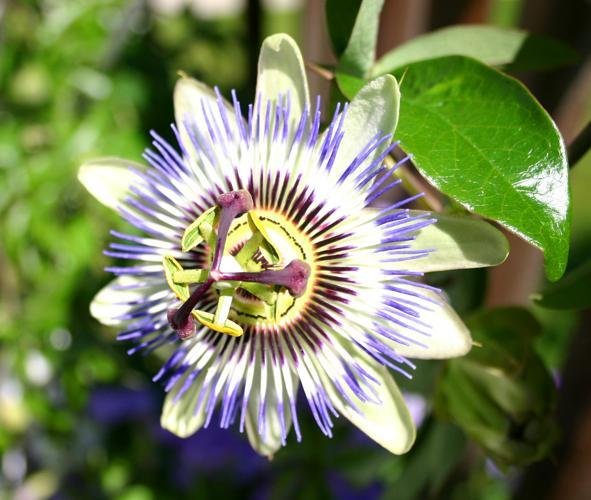

In [ ]:
from IPython.display import Image
print(cat2names[labels[0]])
Image(filename=f"jpg/image_00001.jpg")

water lily


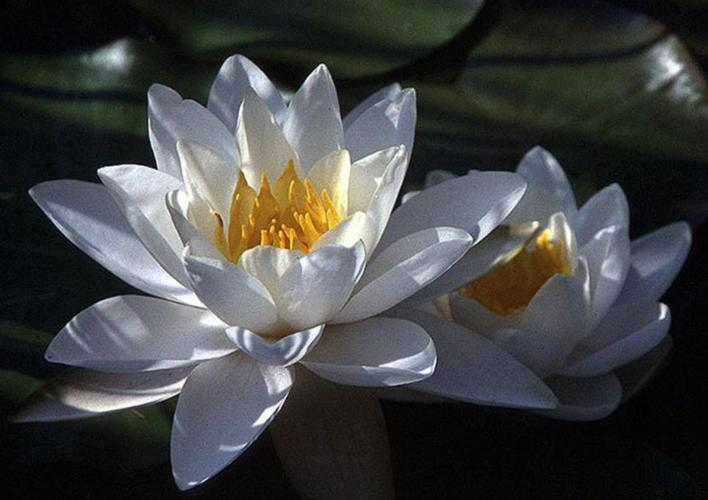

In [ ]:
from IPython.display import Image
print(cat2names[labels[251]])
Image(filename=f"jpg/image_00252.jpg")

Поправим нумерацию

In [ ]:
train_id = split['trnid'].squeeze() - 1
val_id = split['valid'].squeeze() - 1
test_id = split['tstid'].squeeze() - 1

In [ ]:
train_id.shape, val_id.shape, test_id.shape

((1020,), (1020,), (6149,))

И поменяем тестовый и обучающий датасет местами

In [ ]:
train_id, test_id = test_id, train_id

In [ ]:
import os
import shutil


def create_datasetdir(rootdir, inds):
    try:
        os.mkdir(rootdir)
    except FileExistsError:
        pass

    class_paths = {}
    for ind in inds:
       path = f"jpg/image_0{(ind+1):04}.jpg" # 1-based indexing
       name = os.path.basename(path)
       label = cat2names[labels[ind]]
       if not label in class_paths:
           class_paths[label] = os.path.join(rootdir, label)
           try:
               os.mkdir(class_paths[label])
           except FileExistsError:
               pass
       new_path = os.path.join(class_paths[label], name)
       shutil.copy(path, new_path)

In [ ]:
create_datasetdir("train", train_id)
create_datasetdir("test", test_id)
create_datasetdir("val", val_id)

In [ ]:
from torchvision.datasets import ImageFolder

In [ ]:
train_dataset = ImageFolder("train")
val_dataset = ImageFolder("val")
test_dataset = ImageFolder("test")

In [ ]:
assert train_dataset.class_to_idx == val_dataset.class_to_idx
assert train_dataset.class_to_idx == test_dataset.class_to_idx

Посмотрим на размер изображений в нашем датасете

In [ ]:
train_dataset[0][0].size

(500, 667)

In [ ]:
train_dataset[1][0].size

(500, 532)

In [ ]:
from torchvision.transforms import PILToTensor

Видим, что у них разные размеры. При этом размеры отличаются несильно - потому просто будем преобразовывать изображения в train и test при помощи Resize к одному размеру.
Если бы размеры картинок сильно отличались, мы так cделать строго говоря не могли - где гарантия, что при преобразовании у нас расстояния на одном изображении будут похожими на расстояния на другом? А конволюции-то локальны и полагаются на это предположение

Можно решать эту проблему по-разному.

Можно узнать, каковы минимальная ширины и высота в обучающем датасете.

Давайте просто будем на каждом шаге обучения случайным образом обрезать вырезать из каждой картинки случайную область (500, 500)

В этом нам поможет трансформация torch.vision.transforms.RandomCrop

In [ ]:
from torchvision.transforms import Resize, Compose, ToTensor


In [ ]:
from torch.utils.data import DataLoader

In [ ]:
import torch
import torch.nn as nn

class CNN_Simple(nn.Module):
    def __init__(self):
        super().__init__()
        self.featurizer = nn.Sequential(nn.Conv2d(in_channels=3, out_channels=16, kernel_size=7),
                                        nn.ReLU(),
                                        nn.MaxPool2d(kernel_size=2),
                                        nn.Conv2d(in_channels=16, out_channels=32, kernel_size=7),
                                        nn.ReLU(),
                                        nn.MaxPool2d(kernel_size=2),
                                        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=7),
                                        nn.ReLU(),
                                        nn.MaxPool2d(kernel_size=2),
                                        nn.Conv2d(in_channels=64, out_channels=128, kernel_size=7),
                                        nn.ReLU(),
                                        nn.MaxPool2d(kernel_size=2))

        self.linear = nn.Sequential(nn.Flatten(),
                                    nn.Linear(512, 256),
                                    nn.ReLU(),
                                    nn.Linear(256, len(cat2names))
                                    )

    def forward(self, x):
        x = self.featurizer(x)
        x = self.linear(x)
        return x

In [ ]:
train_transform = Compose([Resize(size=(128, 128)), ToTensor()])
train_dataset = ImageFolder("train", transform=train_transform)

val_transform = Compose([Resize(size=(128, 128)), ToTensor()])
val_dataset = ImageFolder("val", transform=val_transform)

In [ ]:
device = torch.device("cuda")

In [ ]:
model = # YOUR CODE HERE
optimizer = torch.optim.Adam(model.parameters())
criterion = nn.CrossEntropyLoss()

In [ ]:
train_loader = DataLoader( # YOUR CODE HERE, batch_size=512, shuffle=True)
val_loader = DataLoader( # YOUR CODE HERE, batch_size=512, shuffle=False)

In [ ]:
for epoch in range(10):
  print(epoch)
  model.train()

  train_loss = 0
  for X, y in train_loader:
      optimizer.zero_grad()
      X = X.float().to(device)
      y = y.to(device)

      pred_y = model(X)
      loss = criterion(pred_y, y)
      train_loss += loss.detach() * X.shape[0]
      loss.backward()
      optimizer.step()
  print(train_loss / len(train_dataset))
  model.eval()
  val_loss = 0
  with torch.no_grad():
      for X, y in val_loader:
          X = X.float().to(device)
          y = y.to(device)

          pred_y = model(X)
          val_loss += criterion(pred_y, y) * X.shape[0]
  print(val_loss / len(val_dataset))

Видим:

1) что учится это медленно. Для глубоких нейросетей, для большой сходимости, нужны особые приемы, которые мы разберем на следующем занятии;

2) Переобучается - качество на валидации начинает падать, а на трайне - расти. Кроме того, почти сразу видно большой гэп между качеством на трейне и валидации. Это само по себе еще не переобучение, но говорит о том, что данные в принципе отличаются и нейросеть плохо генерализует.





С переобучением можно бороться по-разному. Будь у нас качество на валидации хоть в какой-то момент приемлемое - просто бы прерывали обучение в этот момент. Тоже обсудим в следующем занятии.

## Transfer learning

Можно взять предобученную нейросеть, заменить в ней последние слои и обучать только их.

In [ ]:
from torchvision import models, transforms

In [ ]:
train_transform = val_transform  = transforms.Compose([
    transforms.Resize(size=(224,  224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])


In [ ]:
train_dataset = ImageFolder("train", transform=train_transform)

val_dataset = ImageFolder("val", transform=val_transform)

In [ ]:
def set_parameter_requires_grad(model, feature_extracting):
    if feature_extracting:
        for param in model.parameters():
            param.requires_grad = False

In [ ]:
model  = models.resnet152(pretrained=True)
set_parameter_requires_grad(model, True)
model.fc = nn.Linear(2048, out_features=len(cat2names))

In [ ]:
model = model.to(device)
optimizer = torch.optim.Adam(model.fc.parameters())
criterion = nn.CrossEntropyLoss()
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

In [ ]:
for epoch in range(10):
  print(epoch)
  model.train()

  train_loss = 0
  for X, y in train_loader:
      optimizer.zero_grad()
      X = X.float().to(device)
      y = y.to(device)

      # YOUR CODE HERE
      # PASS X to model and get prediction
      loss = criterion(pred_y, y)
      train_loss += loss.detach() * X.shape[0]
      # YOUR CODE HERE
      # BACKPROP
      # OPTIMIZER STEP
  print(train_loss / len(train_dataset))
  model.eval()
  val_loss = 0
  with torch.no_grad():
      for X, y in val_loader:
          X = X.float().to(device)
          y = y.to(device)

          pred_y = model(X)
          val_loss += criterion(pred_y, y) * X.shape[0]
  print(val_loss / len(val_dataset))

In [ ]:
model.eval()
y_pred = []
y_real = []
with torch.no_grad():
    for X, y in val_loader:
        X = X.float().to(device)
        y = y.to(device)

        pred_y = model(X)
        y_pred.append(torch.argmax(pred_y, axis=1).cpu().numpy())
        y_real.append(y.cpu().numpy())

In [ ]:
y_real = np.concatenate(y_real)
y_pred = np.concatenate(y_pred)

In [ ]:
print(f"Accuracy: {(y_real == y_pred).mean():.03f}")

Качество в разы лучше. Мораль - если есть предобученная модель от кого-то - обязательно пробуем использовать эту модель.

## *Аугментация

Можно добавить аугментации в обучающий набор - будем на каждой эпохе посылать в нейросеть не обычное изображение, а немного видоизмененное (при этом подбирая трансформации так, чтобы класс изображения не поменялся)

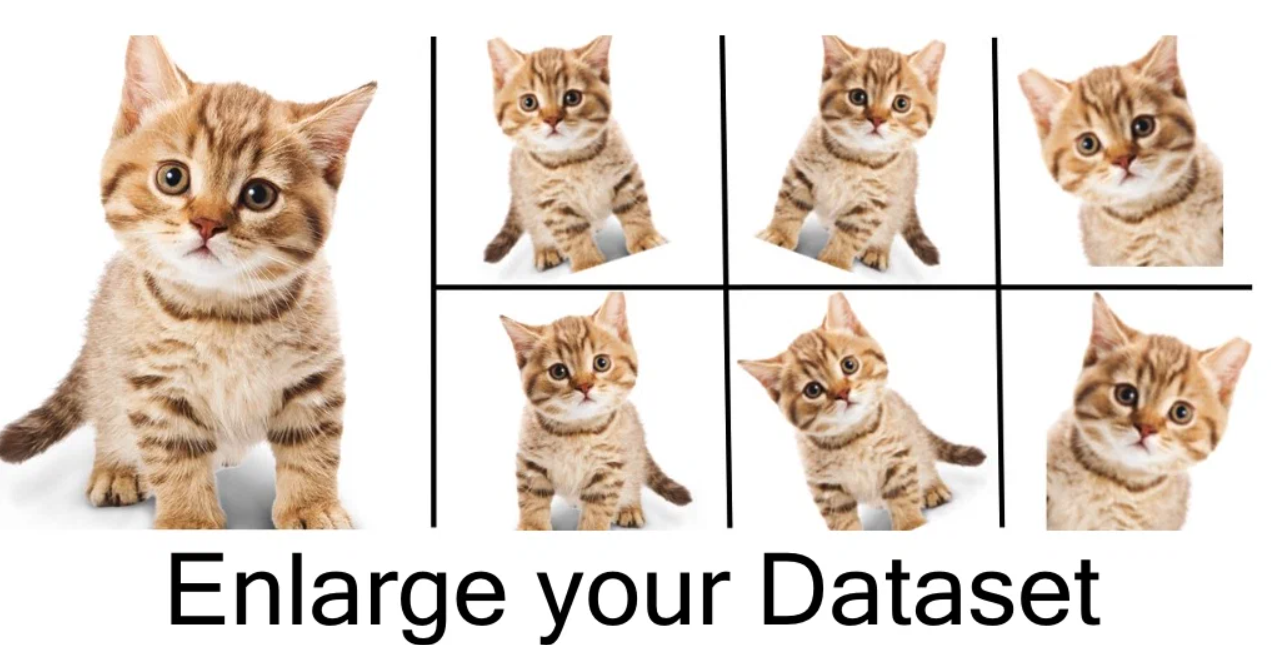

Таких трансформаций можно придумать много. Многие из них есть в torchvision.transforms

То, что они там есть не означает, что они подойдут для вашей задачи. Условно - изменение цвета изображения не всегда искажает класс, но в случае цветов - вполне может



In [ ]:
import PIL.Image
import matplotlib.pyplot as plt
def imshow(img, transform):
    """helper function to show data augmentation
    :param img: path of the image
    :param transform: data augmentation technique to apply"""

    img = PIL.Image.open(img)
    fig, ax = plt.subplots(1, 2, figsize=(15, 4))
    ax[0].set_title(f'original image {img.size}')
    ax[0].imshow(img)
    img = transform(img)
    ax[1].set_title(f'transformed image {img.size}')
    ax[1].imshow(img)

### Обрезание

In [ ]:
import torchvision.transforms as transforms
loader_transform = transforms.CenterCrop(400)
imshow('jpg/image_00001.jpg', loader_transform)

In [ ]:

loader_transform = transforms.RandomCrop(400)
imshow('jpg/image_00001.jpg', loader_transform)

### Вращения

In [ ]:
loader_transform = transforms.RandomVerticalFlip(p=1)
imshow('jpg/image_00001.jpg', loader_transform)

In [ ]:
loader_transform = transforms.RandomHorizontalFlip(p=1)
imshow('jpg/image_00001.jpg', loader_transform)

In [ ]:
loader_transform = transforms.RandomRotation( (-20, 20))
imshow('jpg/image_00001.jpg', loader_transform)

### Работа с цветом

In [ ]:
loader_transform = transforms.ColorJitter(brightness=2)
imshow('jpg/image_00001.jpg', loader_transform)

In [ ]:
loader_transform = transforms.ColorJitter(contrast=2)
imshow('jpg/image_00001.jpg', loader_transform)

In [ ]:
loader_transform = transforms.ColorJitter(saturation=5)
imshow('jpg/image_00001.jpg', loader_transform)

### Соберем эти трансформации

In [ ]:
train_transform = transforms.Compose([
    transforms.RandomChoice([transforms.CenterCrop(400), transforms.RandomCrop(400)]),
    transforms.RandomApply([transforms.RandomChoice([transforms.RandomVerticalFlip(p=1),
                             transforms.RandomHorizontalFlip(p=1),
                             transforms.RandomRotation( (-20, 20))])],
                           p=0.7),
    transforms.RandomApply([transforms.RandomChoice([transforms.ColorJitter(brightness=2),
                            transforms.ColorJitter(contrast=2),
                            transforms.ColorJitter(saturation=5)])]
                            ),
    Resize(size=(128, 128)),
    transforms.ToTensor()])

In [ ]:
train_dataset = ImageFolder("train", transform=train_transform)

val_transform = Compose([Resize(size=(128, 128)), ToTensor()])
val_dataset = ImageFolder("val", transform=val_transform)

In [ ]:
model = CNN_Simple().to(device)
optimizer = torch.optim.Adam(model.parameters())
criterion = nn.CrossEntropyLoss()
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

In [ ]:
for epoch in range(10):
  print(epoch)
  model.train()

  train_loss = 0
  for X, y in train_loader:
      optimizer.zero_grad()
      X = X.float().to(device)
      y = y.to(device)

      pred_y = model(X)
      loss = criterion(pred_y, y)
      train_loss += loss.detach() * X.shape[0]
      loss.backward()
      optimizer.step()
  print(train_loss / len(train_dataset))
  model.eval()
  val_loss = 0
  with torch.no_grad():
      for X, y in val_loader:
          X = X.float().to(device)
          y = y.to(device)

          pred_y = model(X)
          val_loss += criterion(pred_y, y) * X.shape[0]
  print(val_loss / len(val_dataset))

Посмотрим, какомуу качеств соответствует полученный лосс. Посчитаем просто accuracy

In [ ]:
test_dataset = ImageFolder("test", transform=val_transform)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

In [ ]:
model.eval()
y_pred = []
y_real = []
with torch.no_grad():
    for X, y in test_loader:
        X = X.float().to(device)
        y = y.to(device)

        pred_y = model(X)
        y_pred.append(torch.argmax(pred_y, axis=1).cpu().numpy())
        y_real.append(y.cpu().numpy())

In [ ]:
y_real = np.concatenate(y_real)
y_pred = np.concatenate(y_pred)

In [ ]:
print(f"Accuracy: {(y_real == y_pred).mean():.03f}")

Это, конечно, лучше случайного угадывания для 102 классов, но явно не сильно.

А как сделать лучше?

## *Self-supervised pretrained

Также можно использовать модели, обученные в self-supervised режиме. Иногда они дают результаты лучше, чем supervised-модели

In [ ]:

!pip install lightning-bolts

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.8/300.8 kB 6.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.5/829.5 kB 18.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 868.8/868.8 kB 23.6 MB/s eta 0:00:00
ERROR: Operation cancelled by user


In [ ]:
from pl_bolts.models.self_supervised import SimCLR

# load resnet50 pretrained using SimCLR on imagenet
weight_path = 'https://pl-bolts-weights.s3.us-east-2.amazonaws.com/simclr/bolts_simclr_imagenet/simclr_imagenet.ckpt'
simclr = SimCLR.load_from_checkpoint(weight_path, strict=False)

simclr_resnet50 = simclr.encoder
simclr_resnet50 = simclr_resnet50.eval()

ModuleNotFoundError: No module named 'pl_bolts'

In [ ]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.featurizer = simclr_resnet50
        set_parameter_requires_grad(self.featurizer, True)
        self.fc = nn.Linear(2048, len(cat2names))
    def forward(self, x):
        x = self.featurizer(x)
        x = x[0] # featurizer returns list
        x = self.fc(x)
        return x

In [ ]:
model = Model().to(device)
optimizer = torch.optim.Adam(model.fc.parameters())
criterion = nn.CrossEntropyLoss()
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

In [ ]:
for epoch in range(10):
  print(epoch)
  model.train()

  train_loss = 0
  for X, y in train_loader:
      optimizer.zero_grad()
      X = X.float().to(device)
      y = y.to(device)

      pred_y = model(X)
      loss = criterion(pred_y, y)
      train_loss += loss.detach() * X.shape[0]
      loss.backward()
      optimizer.step()
  print(train_loss / len(train_dataset))
  model.eval()
  val_loss = 0
  with torch.no_grad():
      for X, y in val_loader:
          X = X.float().to(device)
          y = y.to(device)

          pred_y = model(X)
          val_loss += criterion(pred_y, y) * X.shape[0]
  print(val_loss / len(val_dataset))

In [ ]:
model.eval()
y_pred = []
y_real = []
with torch.no_grad():
    for X, y in val_loader:
        X = X.float().to(device)
        y = y.to(device)

        pred_y = model(X)
        y_pred.append(torch.argmax(pred_y, axis=1).cpu().numpy())
        y_real.append(y.cpu().numpy())

In [ ]:
y_real = np.concatenate(y_real)
y_pred = np.concatenate(y_pred)

In [ ]:
print(f"Accuracy: {(y_real == y_pred).mean():.03f}")

Но не в этот раз(

Строго говоря - мы не использовали полностью все преимущества self-supervised подхода (разберем позже). Конкретно - можно дообучать загруженную модель на ВСЕМ нашем датасете (не передавая метки классов), а уже затем тренировать классификатор.

Data leakage при этом не произойдет